In [ ]:
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.nlp.preprocessing import clean_text
from src.llm.llm_analyzer import analyze_with_llm

In [ ]:
svm_model = joblib.load("../models/svm_model.pkl")
tfidf_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

SVM model loaded
TF-IDF vectorizer loaded
Number of intents: 77


In [ ]:
test_df = pd.read_csv("../data/processed/test_processed.csv")

Test shape: (3080, 3)
                                                text  \
0                           How do I locate my card?   
1  I still have not received my new card, I order...   
2  I ordered a card but it has not arrived. Help ...   
3   Is there a way to know when my card will arrive?   
4                       My card has not arrived yet.   

                                          clean_text      category  
0                            how do i locate my card  card_arrival  
1  i still have not received my new card i ordere...  card_arrival  
2  i ordered a card but it has not arrived help p...  card_arrival  
3    is there a way to know when my card will arrive  card_arrival  
4                        my card has not arrived yet  card_arrival  


In [ ]:
experiment_df = (
    test_df
    .groupby("category", group_keys=False)
    .sample(n=2, random_state=42)
    .reset_index(drop=True)
)

Experiment shape: (154, 3)
Number of intents: 77
category
Refund_not_showing_up                      2
activate_my_card                           2
age_limit                                  2
apple_pay_or_google_pay                    2
atm_support                                2
                                          ..
virtual_card_not_working                   2
visa_or_mastercard                         2
why_verify_identity                        2
wrong_amount_of_cash_received              2
wrong_exchange_rate_for_cash_withdrawal    2
Name: count, Length: 77, dtype: int64


In [9]:
def predict_ml(text):
    clean = clean_text(text)
    vector = tfidf_vectorizer.transform([clean])

    prediction = svm_model.predict(vector)[0]

    scores = svm_model.decision_function(vector)[0]
    sorted_scores = np.sort(scores)[::-1]

    margin = sorted_scores[0] - sorted_scores[1]

    return prediction, margin

In [ ]:
ml_predictions = []
ml_margins = []

start_time = time.perf_counter()

for text in experiment_df["text"]:

    prediction, margin = predict_ml(text)

    ml_predictions.append(prediction)
    ml_margins.append(margin)

ml_time = time.perf_counter() - start_time

experiment_df["ml_prediction"] = ml_predictions
experiment_df["ml_margin"] = ml_margins

ml_accuracy = (
    experiment_df["ml_prediction"]
    == experiment_df["category"]
).mean()

print("ML-only accuracy:", round(ml_accuracy, 4))
print("ML-only processing time:", round(ml_time, 4), "seconds")

ML-only accuracy: 0.8831
ML-only time: 0.2311 seconds


In [ ]:
CONFIDENCE_THRESHOLD = 0.5

llm_candidates = experiment_df[
    experiment_df["ml_margin"] < CONFIDENCE_THRESHOLD
]

ml_coverage = (
    len(experiment_df) - len(llm_candidates)
) / len(experiment_df)

llm_fallback_rate = (
    len(llm_candidates) / len(experiment_df)
)

print("Total tickets:", len(experiment_df))
print("ML-handled tickets:", len(experiment_df) - len(llm_candidates))
print("LLM fallback candidates:", len(llm_candidates))
print("ML coverage:", round(ml_coverage * 100, 2), "%")
print("LLM fallback rate:", round(llm_fallback_rate * 100, 2), "%")

Total tickets: 154
ML-handled tickets: 118
LLM fallback candidates: 36
ML coverage: 76.62 %
LLM fallback rate: 23.38 %


In [ ]:
llm_predictions = []
llm_latencies = []

for text in llm_candidates["text"]:

    start_time = time.perf_counter()

    result = analyze_with_llm(text)

    latency = time.perf_counter() - start_time

    llm_predictions.append(result.intent)
    llm_latencies.append(latency)

Intent: atm_support | Latency: 1.26 sec
Intent: transfer_timing | Latency: 1.28 sec
Intent: balance_not_updated_after_cheque_or_cash_deposit | Latency: 1.21 sec
Intent: exchange_via_app | Latency: 1.13 sec
Intent: card_acceptance | Latency: 0.63 sec
Intent: card_arrival | Latency: 1.05 sec
Intent: card_arrival | Latency: 0.96 sec
Intent: card_not_working | Latency: 6.21 sec
Intent: card_payment_wrong_exchange_rate | Latency: 8.88 sec
Intent: cash_withdrawal_charge | Latency: 5.57 sec
Intent: cash_withdrawal_not_recognised | Latency: 12.12 sec
Intent: compromised_card | Latency: 4.6 sec
Intent: card_payment_not_recognised | Latency: 5.89 sec
Intent: country_support | Latency: 8.13 sec
Intent: declined_card_payment | Latency: 9.29 sec
Intent: declined_card_payment | Latency: 10.97 sec
Intent: card_payment_not_recognised | Latency: 3.32 sec
Intent: disposable_card_limits | Latency: 12.35 sec
Intent: exchange_charge | Latency: 11.05 sec
Intent: pending_card_payment | Latency: 10.38 sec
Int

KeyboardInterrupt: 

In [15]:
completed_llm_candidates = llm_candidates.iloc[:34].copy()

completed_llm_candidates["llm_prediction"] = llm_predictions
completed_llm_candidates["llm_latency"] = llm_latencies

llm_accuracy = (
    completed_llm_candidates["llm_prediction"]
    == completed_llm_candidates["category"]
).mean()

print("Completed LLM evaluations:", len(completed_llm_candidates))
print("LLM fallback accuracy:", round(llm_accuracy, 4))
print(
    "Average LLM latency:",
    round(np.mean(llm_latencies), 3),
    "seconds"
)
print(
    "Minimum LLM latency:",
    round(np.min(llm_latencies), 3),
    "seconds"
)
print(
    "Maximum LLM latency:",
    round(np.max(llm_latencies), 3),
    "seconds"
)

Completed LLM evaluations: 34
LLM fallback accuracy: 0.6765
Average LLM latency: 7.213 seconds
Minimum LLM latency: 0.63 seconds
Maximum LLM latency: 13.24 seconds


In [16]:
hybrid_predictions = experiment_df["ml_prediction"].copy()

completed_indices = completed_llm_candidates.index

hybrid_predictions.loc[completed_indices] = (
    completed_llm_candidates["llm_prediction"]
)

experiment_df["hybrid_prediction"] = hybrid_predictions

hybrid_accuracy = (
    experiment_df["hybrid_prediction"]
    == experiment_df["category"]
).mean()

print(
    "Hybrid accuracy:",
    round(hybrid_accuracy, 4)
)

Hybrid accuracy: 0.8896


In [17]:
experiment_summary = pd.DataFrame({
    "Metric": [
        "Experiment Tickets",
        "ML-only Accuracy",
        "Hybrid Accuracy",
        "Accuracy Improvement",
        "ML Coverage",
        "LLM Fallback Rate",
        "LLM Fallback Accuracy",
        "Average ML Processing Time",
        "Average LLM Latency",
        "LLM Evaluations Completed",
        "LLM Evaluations Interrupted"
    ],
    "Value": [
        len(experiment_df),
        round(ml_accuracy, 4),
        round(hybrid_accuracy, 4),
        round(hybrid_accuracy - ml_accuracy, 4),
        round(ml_coverage, 4),
        round(llm_fallback_rate, 4),
        round(llm_accuracy, 4),
        round(ml_time, 4),
        round(np.mean(llm_latencies), 4),
        len(completed_llm_candidates),
        len(llm_candidates) - len(completed_llm_candidates)
    ]
})

experiment_summary

,Metric,Value
0,Experiment Tickets,154.0000
1,ML-only Accuracy,0.8831
2,Hybrid Accuracy,0.8896
3,Accuracy Improvement,0.0065
4,ML Coverage,0.7662
5,LLM Fallback Rate,0.2338
6,LLM Fallback Accuracy,0.6765
7,Average ML Processing Time,0.2311
8,Average LLM Latency,7.2133
9,LLM Evaluations Completed,34.0000


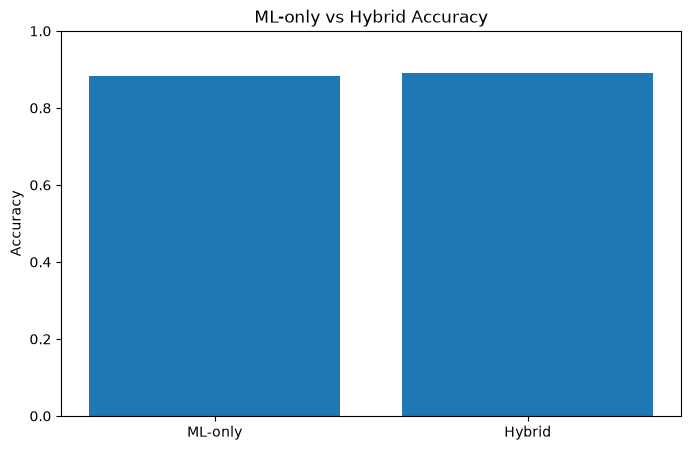

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["ML-only", "Hybrid"],
    [ml_accuracy, hybrid_accuracy]
)

plt.ylabel("Accuracy")
plt.title("ML-only vs Hybrid Accuracy")
plt.ylim(0, 1)

plt.show()

In [19]:
routing_df = pd.DataFrame({
    "Route": ["ML", "LLM"],
    "Tickets": [
        len(experiment_df) - len(llm_candidates),
        len(llm_candidates)
    ]
})

routing_df

,Route,Tickets
0,ML,118
1,LLM,36


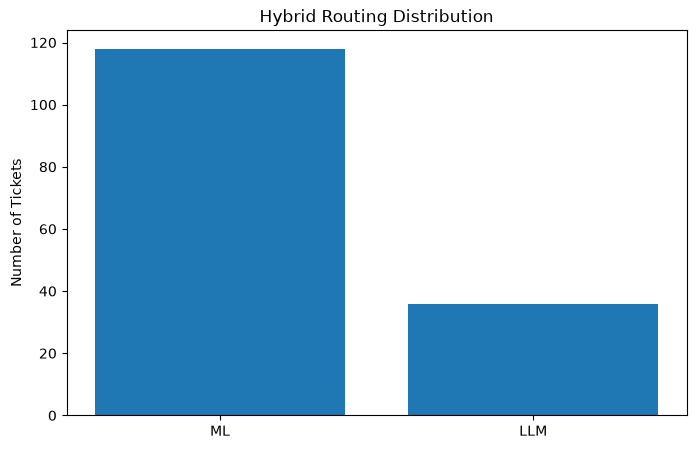

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    routing_df["Route"],
    routing_df["Tickets"]
)

plt.ylabel("Number of Tickets")
plt.title("Hybrid Routing Distribution")

plt.show()